<a href="https://colab.research.google.com/github/gabifiap/CP_SERS/blob/main/Desafio_Final_Energia_ONS_API_Final_(1)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
# Desenvolva aqui o DESAFIO 1

In [6]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [7]:
dados.shape

(336, 11)

In [8]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [10]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


Data / Hora - *din_referenciautc, dat_atualizacaodat e referenciautcval*

Área de Carga - *cod_areacargadin*

Valor de Carga - *val_cargaglobal, val_cargaglobalcons, val_cargaglobalsmmgd, val_carganaosupervisionada, val_cargasupervisionada, val_carganaosupervisionada, val_cargammgd*



## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
# Desenvolva aqui o DESAFIO 2

In [11]:
dados = dados.rename(
    columns={
        "cod_areacargadin": "Area_carga",
        "dat_atualizacaodat": "Data_hora",
        "din_referenciadin": "Data_ref",
        "referenciautcval": "Data_horamed",
        "val_cargaglobal": "Carga_global",
        "val_cargaglobalcons": "Carga_global_cons",
        "val_cargaglobalsmmgd": "Carga_global_smmgd",
        "val_cargasupervisionada": "Carga_supervisionada",
        "val_carganaosupervisionada": "Carga_nao_supervisionada",
        "val_cargammgd": "Carga_mmgd",
        "val_consistencia": "Consistencia",
    }
)

In [12]:
colunas_necessarias = ["cod_areacarga", "din_atualizacao", "din_referenciautc", "Carga_global", "Consistencia"]
df_carga = dados[colunas_necessarias].copy()
df_carga.head()

,cod_areacarga,din_atualizacao,din_referenciautc,Carga_global,Consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01T03:30:00.000Z,15913.618,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01T04:00:00.000Z,15251.414,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01T04:30:00.000Z,14606.733,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01T05:00:00.000Z,14182.290,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01T05:30:00.000Z,13838.488,0


In [13]:
nulos = df_carga.isnull().sum()
print("--- Valores Ausentes por Atributo ---")
print(nulos)

--- Valores Ausentes por Atributo ---
cod_areacarga        0
din_atualizacao      0
din_referenciautc    0
Carga_global         0
Consistencia         0
dtype: int64


In [14]:
print(df_carga.dtypes)

cod_areacarga         object
din_atualizacao       object
din_referenciautc     object
Carga_global         float64
Consistencia           int64
dtype: object


In [15]:
df_carga["din_referenciautc"] = pd.to_datetime(df_carga["din_referenciautc"])

In [16]:
df_carga["Carga_global"] = pd.to_numeric(
    df_carga["Carga_global"], errors="coerce"
)

In [17]:
print("Tipos de Dados Após Tratamento")
print(df_carga.dtypes)
print("\n Primeiras Linhas do Novo DataFrame")
print(df_carga.head())

Tipos de Dados Após Tratamento
cod_areacarga                     object
din_atualizacao                   object
din_referenciautc    datetime64[ns, UTC]
Carga_global                     float64
Consistencia                       int64
dtype: object

 Primeiras Linhas do Novo DataFrame
  cod_areacarga           din_atualizacao         din_referenciautc  \
0            SP  2026-08-14T05:58:29.574Z 2025-08-01 03:30:00+00:00   
1            SP  2026-08-14T05:58:29.574Z 2025-08-01 04:00:00+00:00   
2            SP  2026-08-14T05:58:29.574Z 2025-08-01 04:30:00+00:00   
3            SP  2026-08-14T05:58:29.574Z 2025-08-01 05:00:00+00:00   
4            SP  2026-08-14T05:58:29.574Z 2025-08-01 05:30:00+00:00   

   Carga_global  Consistencia  
0     15913.618             0  
1     15251.414             0  
2     14606.733             0  
3     14182.290             0  
4     13838.488             0  


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
# Desenvolva aqui o DESAFIO 3

In [18]:
carga_min = df_carga["Carga_global"].min()
carga_max = df_carga["Carga_global"].max()
carga_media = df_carga["Carga_global"].mean()
mediana = df_carga["Carga_global"].median()
amplitude = carga_max - carga_min
total_medicoes = df_carga["Carga_global"].count()  # Desconsidera valores nulos (NaN)

print(f"Carga Mínima: {carga_min}")
print(f"Carga Máxima: {carga_max}")
print(f"Carga Média: {carga_media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Quantidade Total de Medições: {total_medicoes}")

Carga Mínima: 12139.253
Carga Máxima: 23185.312
Carga Média: 17870.83
Mediana: 18199.13
Amplitude: 11046.06
Quantidade Total de Medições: 336


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
# Desenvolva aqui o DESAFIO 4

In [19]:
# 1. Cálculo do limiar (90% da carga máxima)
carga_maxima = df_carga["Carga_global"].max()
limiar = 0.90 * carga_maxima

# 2. Filtrar registros com carga superior ao limiar (Alta Demanda)
df_alta_demanda = df_carga[df_carga["Carga_global"] > limiar].copy()

# 3. Contagem de registros de alta demanda e cálculo do percentual
qtd_alta_demanda = len(df_alta_demanda)
total_registros = df_carga["Carga_global"].count()  # Apenas valores válidos
percentual = (qtd_alta_demanda / total_registros) * 100

# 4. Identificação da carga máxima e momento do pico
idx_pico = df_carga["Carga_global"].idxmax()
valor_pico = df_carga.loc[idx_pico, "Carga_global"]

# Verifica se a coluna de data/hora existe no DataFrame
if "din_referenciautc" in df_carga.columns:
    data_hora_pico = df_carga.loc[idx_pico, "din_referenciautc"]
else:
    data_hora_pico = "Coluna de data/hora não identificada"

# Exibição dos resultados
print(f"Limiar de Alta Demanda (90% do máximo): {limiar:.2f}")
print(f"Quantidade de registros em alta demanda: {qtd_alta_demanda}")
print(f"Percentual em relação ao total: {percentual:.2f}%")
print(f"Maior valor de carga (Pico): {valor_pico:.2f}")
print(f"Data e Horário do Pico: {data_hora_pico}")

Limiar de Alta Demanda (90% do máximo): 20866.78
Quantidade de registros em alta demanda: 50
Percentual em relação ao total: 14.88%
Maior valor de carga (Pico): 23185.31
Data e Horário do Pico: 2025-08-01 22:00:00+00:00


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
# Desenvolva aqui o DESAFIO 5

In [20]:
# Critério escolhido: carga acima da média

# 1. Critério
carga_media_criterio = df_carga["Carga_global"].mean()

# 2. Novo DataFrame com os registros acima da média
df_acima_media = df_carga[df_carga["Carga_global"] > carga_media_criterio].copy()

# 3. Quantidade de registros
qtd_acima_media = len(df_acima_media)

# 4. Percentual em relação ao total
percentual_acima_media = (qtd_acima_media / total_registros) * 100

# 5. Comparação com o conjunto de alta demanda (Desafio 4)
print(f"Critério: Carga_global acima da média ({carga_media_criterio:.2f} MW)")
print(f"Quantidade de registros acima da média: {qtd_acima_media}")
print(f"Percentual em relação ao total: {percentual_acima_media:.2f}%\n")

print("--- Comparação com o critério de Alta Demanda (>90% do máximo) ---")
print(f"Alta demanda: {qtd_alta_demanda} registros ({percentual:.2f}%)")
print(f"Acima da média: {qtd_acima_media} registros ({percentual_acima_media:.2f}%)")

diferenca_qtd = qtd_acima_media - qtd_alta_demanda
print(f"\nO critério 'acima da média' é mais abrangente, capturando {diferenca_qtd} registros a mais que o critério de alta demanda.")

Critério: Carga_global acima da média (17870.83 MW)
Quantidade de registros acima da média: 184
Percentual em relação ao total: 54.76%

--- Comparação com o critério de Alta Demanda (>90% do máximo) ---
Alta demanda: 50 registros (14.88%)
Acima da média: 184 registros (54.76%)

O critério 'acima da média' é mais abrangente, capturando 134 registros a mais que o critério de alta demanda.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

In [ ]:
# Desenvolva aqui o DESAFIO 6

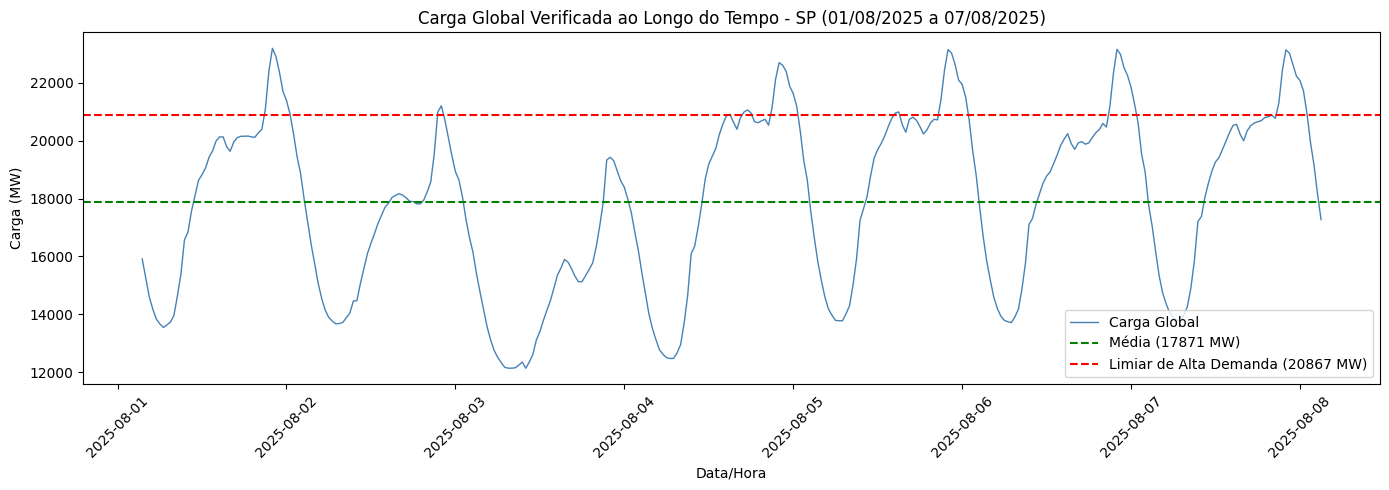

In [21]:
df_plot = df_carga.dropna(subset=["Carga_global", "din_referenciautc"]).sort_values("din_referenciautc")

# Gráfico 1: comportamento da carga ao longo do tempo
plt.figure(figsize=(14, 5))
plt.plot(df_plot["din_referenciautc"], df_plot["Carga_global"], color="steelblue", linewidth=1, label="Carga Global")
plt.axhline(carga_media, color="green", linestyle="--", label=f"Média ({carga_media:.0f} MW)")
plt.axhline(limiar, color="red", linestyle="--", label=f"Limiar de Alta Demanda ({limiar:.0f} MW)")
plt.title("Carga Global Verificada ao Longo do Tempo - SP (01/08/2025 a 07/08/2025)")
plt.xlabel("Data/Hora")
plt.ylabel("Carga (MW)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

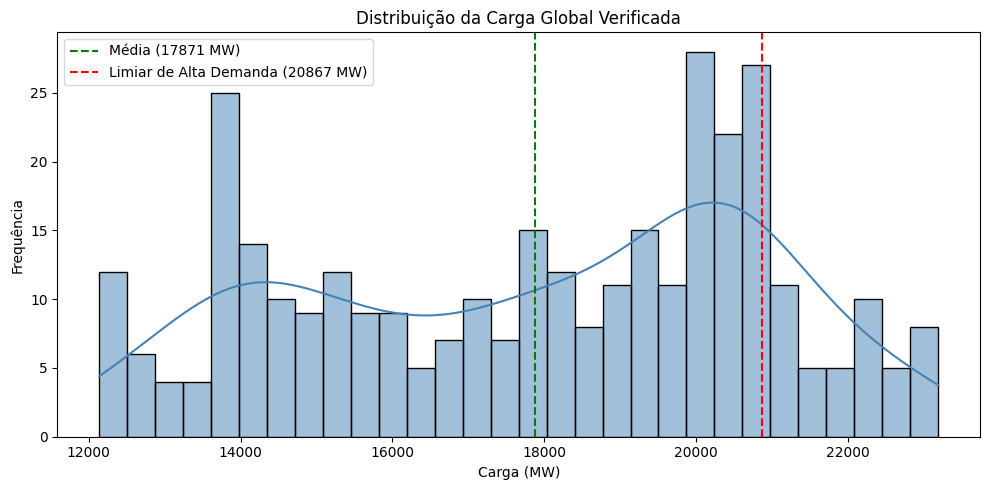

In [22]:
# Gráfico 2: distribuição da carga (escolhido pela equipe)
plt.figure(figsize=(10, 5))
sns.histplot(df_carga["Carga_global"].dropna(), bins=30, color="steelblue", kde=True)
plt.axvline(carga_media, color="green", linestyle="--", label=f"Média ({carga_media:.0f} MW)")
plt.axvline(limiar, color="red", linestyle="--", label=f"Limiar de Alta Demanda ({limiar:.0f} MW)")
plt.title("Distribuição da Carga Global Verificada")
plt.xlabel("Carga (MW)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**